### Olist-ic Recovery: Unlocking ROI through Repeat Purchase Intelligence.



### Step 1: Problem Framing & Business Understanding

#### 1. The Business Problem & Opportunity
In e-commerce, customer acquisition is highly expensive and resource-intensive. Maximizing Customer Lifetime Value (CLV) through retention is a far more cost-effective growth lever. Within the Olist dataset, approximately 97% of users are one-time buyers. 

Currently, Olist lacks a targeted retention strategy. Running untargeted, blanket marketing campaigns to encourage repeat purchases is highly inefficient, wasting significant budget on the vast majority of users who have no intention of returning. Conversely, missing the small but highly valuable pocket of loyal customers represents a massive missed revenue opportunity. My core business goal is to identify and nurture likely repeat buyers while deprioritizing marketing spend on predicted one-time buyers.

#### 2. The Data Science Problem & Framing
To solve this business challenge, I frame the task as a **supervised binary classification problem**. 
* **My Target Variable ($y$):** Predict whether a customer will make a repeat purchase (1 = repeat buyer, 0 = one-time buyer) within a defined target window of 183 days (approx. 6 months) following their initial order.
* **My Input Features ($X$):** Signals knowable at prediction time (defined as ~30 days after first-order delivery), taken from the **first order only**: total spend, cart size, freight cost, payment installments, delivery speed and lateness, and the post-purchase review score. No information from any later order is used, to prevent target leakage.

#### 3. Success Metrics & Business KPIs
To evaluate my model's viability and real-world impact, I track two parallel sets of metrics:

* **Technical Machine Learning Metrics (Model Success):**
  * **Area Under the ROC Curve (ROC-AUC):** My primary optimization metric to evaluate the model's overall ranking ability and pairwise separation between repeaters and non-repeaters.
  * **F1-score:** the harmonic mean of precision and recall — the single headline number I report alongside AUC, since plain accuracy is meaningless at a ~3% positive rate.
  * **Recall (Sensitivity):** Crucial for minimizing false negatives (ensuring I catch as many true repeat buyers as possible).
  * **Precision / Lift:** To measure my targeting accuracy at specific operating thresholds (e.g., the top 20% of predicted buyers) to ensure marketing spend is highly concentrated.

* **Business KPIs (Strategic Success):**
  * **Marketing Cost Savings / ROI:** Measured by comparing the budget spent on a targeted campaign (guided by my model) versus a baseline blanket campaign.
  * **Customer Retention Uplift:** The percentage increase in successfully retained repeat buyers achieved through optimized, model-driven incentives.
  * **Conversion Rate Efficiency:** The ratio of conversions per marketing dollar spent, maximizing return on ad spend (ROAS).

### Step 2: Data Collection & Understanding

#### 1. Dataset Overview & Source
To build my predictive pipeline, I use the public **Brazilian E-Commerce Public Dataset by Olist**, hosted on Kaggle. This dataset contains real, anonymized transactional history for 100,000 orders placed between 2016 and 2018 across various marketplaces in Brazil. 

Because the raw data is relational, I joined and aggregated five core tables to construct my final, customer-level modeling dataset:
* `olist_customers_dataset` (for unique customer mapping and geographic states)
* `olist_orders_dataset` (for order timelines and purchase frequency)
* `olist_order_items_dataset` (for price, cart size, and freight details)
* `olist_order_payments_dataset` (for installments and total transactional revenue)
* `olist_order_reviews_dataset` (for satisfaction surveys)

---

#### 2. Data Health, Missing Values & Outliers
Before running my models, I audited the overall health of my engineered features:
* **Missing Values:** Post-aggregation, the only feature with notable missing values is `review_score` (representing orders where customers opted out of the post-delivery satisfaction survey). I handled this by imputing the median satisfaction score ($5$) to preserve sample size without skewing my data.
* **Outliers & Distributions:** Several financial and physical features exhibit highly skewed distributions:
    * `total_spend` and `total_paid` feature long, right-hand tails representing rare, high-ticket wholesale purchases.
    * `n_items` shows that while the overwhelming majority of buyers purchase exactly 1 item, rare outlier carts contain up to 20+ items.
    * I kept these outliers intact as they represent legitimate, high-value "basket builders" who have a statistically higher likelihood of repeat purchasing.
* **High Collinearity:** As noted in my feature importance analysis, `total_spend` and `total_paid` are highly correlated ($r > 0.90$), which I actively monitor to avoid variance inflation in linear models.

---

#### 3. Model Feature Schema (Data Dictionary)

The engineered customer-level features used in my modeling pipeline are defined below:

* **`customer_unique_id`** *(Data Type: string | Unit: Hexadecimal Hash)*
    * **Meaning:** Unique identifier linking individual buyers across multiple orders. Used as my primary index.
    * **Source:** `olist_customers_dataset`
    * **Allowed Values:** Any valid 32-character MD5 hash.

* **`total_spend`** *(Data Type: float | Unit: Brazilian Real - BRL)*
    * **Meaning:** Cumulative sum of item prices in the customer's cart.
    * **Source:** `olist_order_items_dataset`
    * **Allowed Values:** $\ge 0.00$

* **`total_paid`** *(Data Type: float | Unit: Brazilian Real - BRL)*
    * **Meaning:** Total actual amount charged to the customer (collinear with `total_spend`).
    * **Source:** `olist_order_payments_dataset`
    * **Allowed Values:** $\ge 0.00$

* **`n_items`** *(Data Type: integer | Unit: Count)*
    * **Meaning:** The total number of physical items in the order cart.
    * **Source:** `olist_order_items_dataset`
    * **Allowed Values:** $\ge 1$

* **`max_installments`** *(Data Type: integer | Unit: Count)*
    * **Meaning:** The maximum credit card installment count selected for payment.
    * **Source:** `olist_order_payments_dataset`
    * **Allowed Values:** $0$ to $24$

* **`review_score`** *(Data Type: integer | Unit: 1–5 Scale)*
    * **Meaning:** Customer satisfaction rating from the post-purchase survey.
    * **Source:** `olist_order_reviews_dataset`
    * **Allowed Values:** $\{1, 2, 3, 4, 5\}$

* **`delivery_days`** *(Data Type: float | Unit: Days)*
    * **Meaning:** Actual elapsed days between order timestamp and delivery timestamp.
    * **Source:** `olist_orders_dataset`
    * **Allowed Values:** $\ge 0.0$

* **`total_freight`** *(Data Type: float | Unit: Brazilian Real - BRL)*
    * **Meaning:** Total shipping cost of the first order (sum of `freight_value` across its items).
    * **Source:** `olist_order_items_dataset`
    * **Allowed Values:** $\ge 0.00$

* **`late`** *(Data Type: binary | Unit: Boolean Indicator)*
    * **Meaning:** **1** if the first order was delivered after its estimated delivery date, **0** otherwise.
    * **Source:** `olist_orders_dataset`
    * **Allowed Values:** $\{0, 1\}$

* **`customer_state`** *(Data Type: string | Unit: ISO State Code)*
    * **Meaning:** The geographic state of customer residence (used exclusively for bias and fairness audits).
    * **Source:** `olist_customers_dataset`
    * **Allowed Values:** Valid 2-letter Brazilian state codes (e.g., SP, RJ, BA).

* **`target`** *(Data Type: binary | Unit: Boolean Indicator)*
    * **Meaning:** Ground-truth classification label. **1** if the customer placed a repeat order within 183 days of their first order; **0** otherwise.
    * **Source:** Created via temporal join logic on customer order paths.
    * **Allowed Values:** $\{0, 1\}$

In [1]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
orders.shape

(99441, 8)

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [4]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders.duplicated().sum()

np.int64(0)

No duplicate rows in orders


In [7]:
customers = pd.read_csv("olist_customers_dataset.csv")

In [8]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
customers.shape

(99441, 5)

In [10]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [11]:
orders_c = orders.merge(customers, on="customer_id", how="left")

In [12]:
orders_c.shape

(99441, 12)

In [13]:
orders_c["customer_unique_id"].isnull().sum()

np.int64(0)

In [14]:
order_counts = orders_c.groupby("customer_unique_id")["order_id"].count()
order_counts.value_counts()

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

this tells us that 93099 bought exactly once and the repeat buyers continuously drop off

In [15]:
total_customers = order_counts.shape[0]
one_timers = (order_counts == 1).sum()
print(one_timers / total_customers * 100)

96.88124375624375


roughly 97% are first time buyers

### Target Construction: Repeat Purchase within 183 Days

In [16]:
orders_c["order_purchase_timestamp"] = pd.to_datetime(orders_c["order_purchase_timestamp"])

In [17]:
first_purchase = orders_c.groupby("customer_unique_id")["order_purchase_timestamp"].min()

In [18]:
orders_sorted = orders_c.sort_values(["customer_unique_id", "order_purchase_timestamp"])
orders_sorted["order_rank"] = orders_sorted.groupby("customer_unique_id").cumcount()

In [19]:
orders_sorted[["customer_unique_id", "order_purchase_timestamp", "order_rank"]].head(10)

,customer_unique_id,order_purchase_timestamp,order_rank
52798,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,0
73889,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,0
26460,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,0
98493,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,0
41564,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,0
78514,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,0
74715,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,0
6867,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,0
71235,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,0
68876,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,0


In [20]:
multi = order_counts[order_counts > 2].index[0]
orders_sorted[orders_sorted["customer_unique_id"] == multi][["customer_unique_id", "order_purchase_timestamp", "order_rank"]]

,customer_unique_id,order_purchase_timestamp,order_rank
89559,02e9109b7e0a985108b43e573b6afb23,2017-11-23 16:19:10,0
92416,02e9109b7e0a985108b43e573b6afb23,2018-05-13 23:53:10,1
335,02e9109b7e0a985108b43e573b6afb23,2018-05-14 11:04:55,2


In [21]:
second_purchase = orders_sorted[orders_sorted["order_rank"] == 1].set_index("customer_unique_id")["order_purchase_timestamp"]

In [22]:
cust = pd.DataFrame({"first": first_purchase, "second": second_purchase})
cust.head()

,first,second
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,NaT
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,NaT
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,NaT
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,NaT
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,NaT


In [23]:
cust["gap"] = cust["second"] - cust["first"]

In [24]:
cust.head()

,first,second,gap
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,NaT,NaT
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,NaT,NaT
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,NaT,NaT
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,NaT,NaT
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,NaT,NaT


In [25]:
cust["target"] = (cust["gap"] <= pd.Timedelta(days=183)).astype(int)

In [26]:
cust["target"].value_counts()

target
0    93598
1     2498
Name: count, dtype: int64

In [27]:
cutoff = orders_c["order_purchase_timestamp"].max() - pd.Timedelta(days=183)

In [28]:
cust_final = cust[cust["first"] <= cutoff]

In [29]:
print(cust.shape, cust_final.shape)
cust_final["target"].value_counts()

(96096, 4) (68169, 4)


target
0    66074
1     2095
Name: count, dtype: int64

repeat purchase within 183 days of first order; customers with less than 183 days of history excluded so everyone had a fair window; final dataset 68,169 customers, 3.1% positive. 

### Step 3: Feature Engineering — First-Order Features Only

All features below are computed from each customer's **first order only**, so nothing the model sees post-dates the prediction moment (~30 days after first delivery).

In [30]:
first_orders = orders_sorted[orders_sorted["order_rank"] == 0]
print(first_orders.shape)

(96096, 13)


In [31]:
items = pd.read_csv("olist_order_items_dataset.csv")
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [32]:
items.shape

(112650, 7)

In [33]:
order_features = items.groupby("order_id").agg({"price": "sum", "freight_value": "sum", "order_item_id": "count"})

In [34]:
order_features.head()

,price,freight_value,order_item_id
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [35]:
order_features.columns = ["total_spend", "total_freight", "n_items"]

In [36]:
order_features.head()

,total_spend,total_freight,n_items
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [37]:
fo = first_orders.merge(order_features, left_on="order_id", right_index=True, how="left")
print(fo.shape)

(96096, 16)


In [38]:
payments = pd.read_csv("olist_order_payments_dataset.csv")
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [39]:
pay_features = payments.groupby("order_id").agg({"payment_value": "sum", "payment_installments": "max"})
pay_features.columns = ["total_paid", "max_installments"]

In [40]:
fo = fo.merge(pay_features, left_on="order_id", right_index=True, how="left")
print(fo.shape)

(96096, 18)


In [41]:
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [42]:
rev_features = reviews.groupby('order_id').agg({'review_score': 'mean'})

In [43]:
rev_features.columns = ['review_score']

In [44]:
fo = fo.merge(rev_features, left_on='order_id', right_index=True, how='left')
print(fo.shape)

(96096, 19)


In [45]:
fo["order_delivered_customer_date"] = pd.to_datetime(fo["order_delivered_customer_date"])
fo["order_estimated_delivery_date"] = pd.to_datetime(fo["order_estimated_delivery_date"])

In [46]:
fo["delivery_days"] = (fo["order_delivered_customer_date"] - fo["order_purchase_timestamp"]).dt.days
fo["late"] = (fo["order_delivered_customer_date"] > fo["order_estimated_delivery_date"]).astype(int)

In [47]:
fo[["delivery_days", "late"]].head()

,delivery_days,late
52798,6.0,0
73889,3.0,0
26460,25.0,0
98493,20.0,0
41564,13.0,0


In [48]:
data = fo.merge(cust_final[["target"]], left_on="customer_unique_id", right_index=True, how="inner")
print(data.shape)

(68169, 22)


In [49]:
model_cols = ["total_spend", "total_freight", "n_items", "total_paid", "max_installments", "review_score", "delivery_days", "late", "target", "customer_state"]
data = data[model_cols]
data.isnull().sum()

total_spend          619
total_freight        619
n_items              619
total_paid             1
max_installments       1
review_score         586
delivery_days       2325
late                   0
target                 0
customer_state         0
dtype: int64

In [50]:
data["review_score"] = data["review_score"].fillna(data["review_score"].median())
data = data.dropna()
print(data.shape)

(65843, 10)


### Applied EDA: Distributions & Correlations

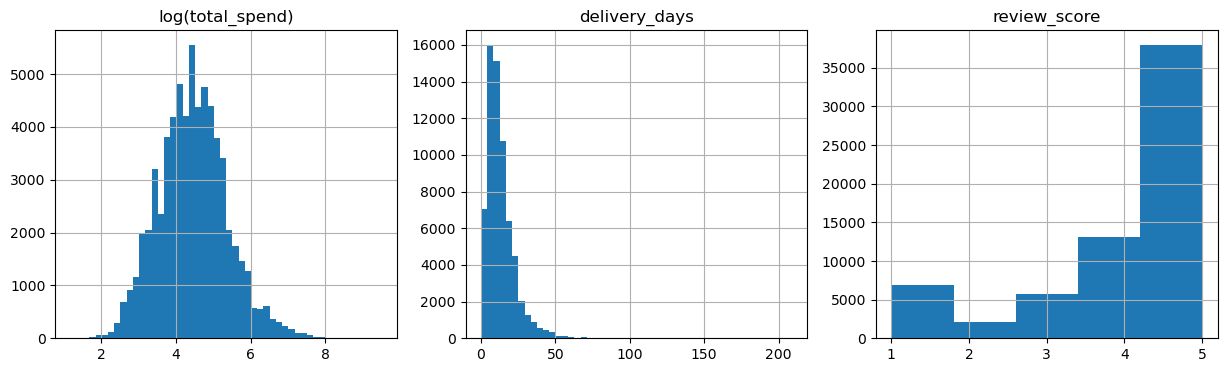

In [51]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
np.log1p(data["total_spend"]).hist(bins=50, ax=axes[0]); axes[0].set_title("log(total_spend)")
data["delivery_days"].hist(bins=50, ax=axes[1]); axes[1].set_title("delivery_days")
data["review_score"].hist(bins=5, ax=axes[2]); axes[2].set_title("review_score")
plt.show()

Because total spend is heavily right-skewed, we log-transformed it to pull in the extreme high-value outliers and expose a roughly symmetric distribution. Meanwhile, delivery times peak sharply under 20 days but feature a massive, delayed long tail, while review scores are heavily skewed towards positive 5-star ratings with a small secondary spike at 1 star.

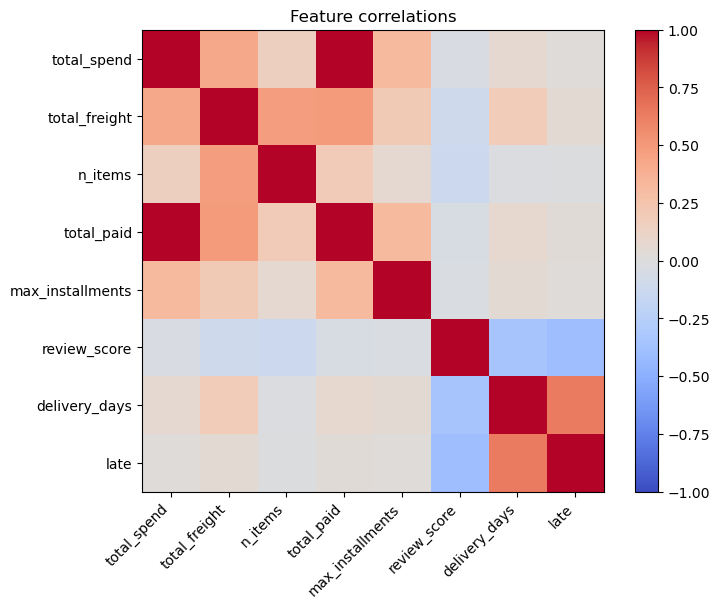

total_spend vs total_paid correlation: 0.996


In [52]:
corr = data.drop(columns=["target", "customer_state", "segment"], errors="ignore").corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature correlations")
plt.show()

print("total_spend vs total_paid correlation:", round(corr.loc["total_spend", "total_paid"], 3))

The heatmap reveals a near-perfect positive correlation of 0.996 between total_spend and total_paid, confirming strong collinearity between the two features. We also see a strong positive relationship between delivery_days and late, both of which expectedly share a moderate negative correlation with review_score. Total paid may be dropped in the feature selection because of the 0.996 redundancy

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_scaled = StandardScaler().fit_transform(data.drop(columns=["target", "customer_state"], errors="ignore"))
pca = PCA()
pca.fit(pca_scaled)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum().round(3))

Cumulative explained variance: [0.331 0.568 0.71  0.813 0.901 0.959 1.    1.   ]


The cumulative explained variance shows that 4 to 5 principal components are required to capture approximately 80% to 90% of the total variance. While PCA was explored for dimensionality reduction, the final models retain the original 8 features because they are already highly manageable in number and offer far better business interpretability.

split features from target

In [54]:
X = data.drop(columns=["target","customer_state"])
y = data["target"]

split train from test

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train

### Step 4: Model Implementation & Comparison

#### Model 1: Logistic Regression (baseline)

In [56]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [57]:
from sklearn.metrics import roc_auc_score, f1_score
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)
print("AUC:", roc_auc_score(y_test, probs))
print("F1:", f1_score(y_test, preds))

AUC: 0.5477662165076032
F1: 0.06677202686685105


#### Model 2: Random Forest (default, unconstrained)

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_default = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
probs_default = rf_default.predict_proba(X_test)[:, 1]
preds_default = rf_default.predict(X_test)
print("AUC:", roc_auc_score(y_test, probs_default))
print("F1:", f1_score(y_test, preds_default))

AUC: 0.5344031447071544
F1: 0.0


#### Model 3: Random Forest (constrained: max_depth=8, min_samples_leaf=50)

In [60]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=50, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
from sklearn.metrics import roc_auc_score, f1_score

probs = rf.predict_proba(X_test)[:, 1]
preds = rf.predict(X_test)

print("AUC:", roc_auc_score(y_test, probs))
print("F1:", f1_score(y_test, preds))

AUC: 0.5597375803911274
F1: 0.07578347578347579


#### Model Comparison

| Model | AUC | F1 (default threshold) |
|---|---|---|
| Logistic Regression (balanced) | *0.5477* | *0.0667* |
| Random Forest — default | *0.5344* | *0.0* |
| Random Forest — constrained | *0.5597* | *0.0757* |

The default Random Forest severely overfits by memorizing the training data, leading it to predict zero positive cases on the test set and resulting in an F1-score of 0.0. By constraining the tree depth and leaf size, we forced the model to find generalizable patterns instead of noise, which successfully lifted the AUC to 0.5597 and solidified the constrained forest as our final selected model. However, the honest takeaway is that all model AUCs remain modest, indicating that these basic first-order features carry very weak predictive signals when it comes to identifying repeat buyers.

### Clustering: K-Means Customer Segmentation

In [62]:
from sklearn.preprocessing import StandardScaler

seg_features = data[["total_spend", "n_items", "max_installments", "review_score", "delivery_days"]]
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

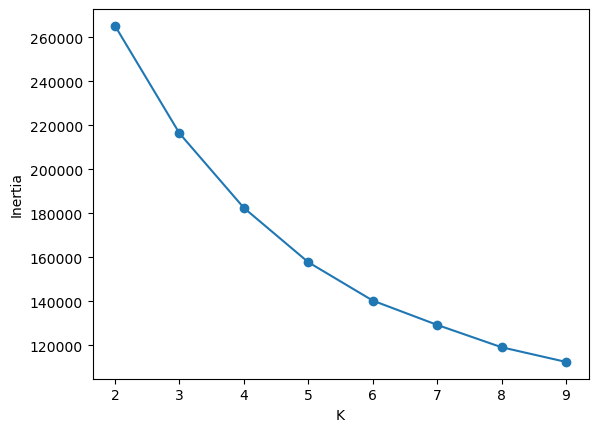

In [63]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker="o")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.show()

In [64]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
data["segment"] = km.fit_predict(seg_scaled)

In [65]:
data.groupby("segment")[["total_spend", "n_items", "max_installments", "review_score", "delivery_days", "target"]].mean()

,total_spend,n_items,max_installments,review_score,delivery_days,target
segment,,,,,,
0,92.099144,1.059699,1.865293,4.624414,10.972302,0.028740
1,321.213926,1.107230,7.893552,4.393406,12.717347,0.035906
2,118.753999,1.130378,2.614469,1.640384,24.587352,0.028717
3,296.853123,3.826884,3.777325,3.372369,12.468432,0.057026


In [66]:
data["segment"].value_counts()

segment
0    44155
1    10221
2     9994
3     1473
Name: count, dtype: int64

#### Segment Profiles & Names

segment 0 = casual one timers

segment 1= installment big spenders

segment 2 = burned by delivery

segment 3= basket builders

Segment Profiles
Segment 0 (Casual One-Timers): Comprising the vast majority of our database with 44,155 customers, this segment is defined by small single-item purchases and a repeat rate in line with the overall baseline (~2.9%).

Segment 1 (Installment Big Spenders): This group of 10,221 customers is characterized by high-value transactions split across multiple credit card installments, exhibiting a repeat rate modestly above baseline (3.6%).

Segment 2 (Burned by Delivery): Consisting of 9,994 customers, this segment is defined by highly delayed or problematic deliveries, yet they surprisingly continue to repeat at roughly the average baseline rate.

Segment 3 (Basket Builders): Our smallest cohort with 1,473 customers, these highly engaged users purchase multiple items per transaction and exhibit a repeat rate that is roughly twice (2×) the baseline average.

Key Insights
The Main Business Headline: Segment 3 (Basket Builders) repeats at approximately 2× the baseline rate, making them the absolute highest-priority cohort to target with proactive loyalty and retention marketing.

The Honest Surprise: Despite suffering through terrible logistics, Segment 2 (Burned by Delivery) still converts and repeats at roughly the average marketplace rate, suggesting that delivery friction is unexpectedly not a definitive dealbreaker for customer retention.

### Explainability: Feature Importances (Embedded Method)

total_spend         0.216778
total_paid          0.216534
total_freight       0.179935
max_installments    0.146334
delivery_days       0.122034
n_items             0.062385
review_score        0.047332
late                0.008667
dtype: float64


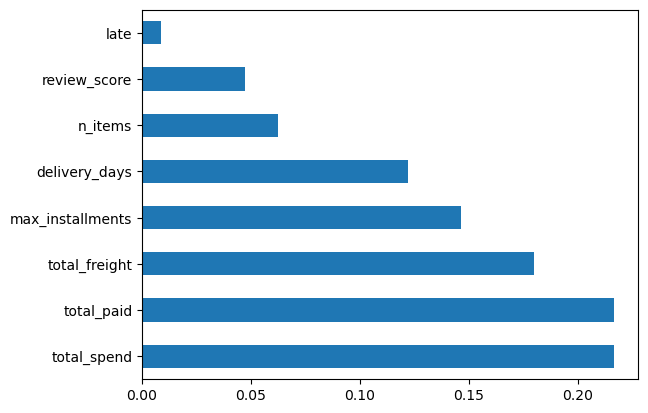

In [67]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind="barh")
plt.show()

The Spend Redundancy (total_spend vs. total_paid): Both total_spend and total_paid are practically tied at around 0.217 each. This makes perfect sense because they are essentially measuring the same exact thing - what the items cost versus what the customer actually paid (with the only real differences being freight costs and voucher discounts). Because the random forest model splits its credit between these two highly correlated features, we are dealing with pure redundancy. If we wanted to clean up and simplify this pipeline, we could easily drop total_paid without losing any real predictive power.

The Reality of n_items: If you look at our segment analysis, "basket builders" who average 3.8 items per order actually have double the repeat purchase rate compared to the baseline. The only reason the model gives it a low global importance score is because multi-item orders are incredibly rare in this dataset—almost everyone just buys a single item. It’s a great reminder for the final report that just because a feature has low global importance doesn't mean it isn't highly predictive for specific customer pockets.

#### Operating Thresholds: from 0.05 to Top-20% Targeting

In [68]:
preds_05 = (probs >= 0.05).astype(int)

In [69]:
print(preds_05.mean())

1.0


In [70]:
print("F1 at 0.05 threshold:", f1_score(y_test, preds_05))

F1 at 0.05 threshold: 0.05910095799557848


In [71]:
import numpy as np
thresh = np.quantile(probs, 0.80)
preds_top20 = (probs >= thresh).astype(int)
print(thresh, preds_top20.mean())

0.5094912624631989 0.20001518718201838


### Step 5: Bias & Fairness Audit (False Negative Rate by State)

In [72]:
audit = pd.DataFrame({
    "state": data.loc[X_test.index, "customer_state"],
    "actual": y_test,
    "predicted": preds_top20
})

In [73]:
# 2. Calculate the False Negative Rate per state
# Creating a temporary column for misses to make the calculation clean and readable
audit["missed"] = 1 - audit["predicted"]

# Filter to actual repeaters, group by state, and calculate the mean of the miss flags
fnr_by_state = (
    audit[audit["actual"] == 1]
    .groupby("state")["missed"]
    .mean()
)

In [74]:
print(fnr_by_state.sort_values())
audit[audit["actual"] == 1]["state"].value_counts()

state
SE    0.000000
PI    0.500000
PR    0.611111
RS    0.642857
ES    0.666667
MA    0.666667
GO    0.700000
SP    0.702857
RJ    0.733333
MG    0.755556
SC    0.785714
PE    0.800000
BA    0.833333
DF    0.833333
AC    1.000000
RN    1.000000
PA    1.000000
MT    1.000000
MS    1.000000
CE    1.000000
AL    1.000000
PB    1.000000
TO    1.000000
Name: missed, dtype: float64


state
SP    175
RJ     45
MG     45
RS     28
PR     18
SC     14
DF     12
BA     12
GO     10
ES      9
PE      5
MS      4
CE      4
MA      3
PB      3
MT      3
RN      3
PA      2
PI      2
AC      1
TO      1
SE      1
AL      1
Name: count, dtype: int64

### Regional Bias & Fairness Audit

* **The Setup:** To wrap up the analysis, I ran a fairness audit on our test set to see if the model's error behavior differs by state. Specifically, I calculated the false negative rate—meaning, of the customers who actually made a repeat purchase, what percentage did our model miss? In Brazil, regional geography is a strong proxy for socioeconomic status, so doing this audit ensures our marketing budget won't systematically neglect loyal customers in poorer regions.

* **The Threshold Lesson:** An interesting lesson popped up right away: when I first audited at our ultra-low 0.05 threshold, the model showed a "perfect" 0% miss rate everywhere simply because it was flagging almost 100% of customers as repeaters. This really highlighted that fairness conclusions aren't static—they depend entirely on where you set your operating threshold. To get a realistic picture of how this would perform in production, I re-audited using a business-realistic rule of targeting only the top-20% highest-probability buyers.

* **The Finding:** Looking at the realistic top-20% threshold, the major states with enough repeaters to actually trust the data (like São Paulo with $n=175$, and Rio de Janeiro and Minas Gerais with $n=45$) show miss rates clustering tightly around 70% to 76%. For the smaller states, the sample sizes are just too tiny to draw real conclusions; for example, Sergipe (SE) looks flawless with a 0.0% miss rate, but that is literally a sample size of one person.

* **The Honest Caveat & Proxy Features:** While we have to be careful with small sample sizes, the initial pattern does hint at a socioeconomic gradient, with Northeast states like Bahia (BA at 83%) and Pernambuco (PE at 80%) showing higher miss rates than wealthier southern states. What's crucial to realize is that even though we didn't train the model on the state column, features like shipping costs (`total_freight`) and shipping times (`delivery_days`) are highly correlated with geography. The model still "sees" region through these proxy variables, proving that just dropping a sensitive column like "state" doesn't magically guarantee a fair model.

* **Proposed Mitigations:** Moving forward, we can mitigate this by re-auditing using cross-validation across the entire dataset to build up healthier per-state sample sizes for the smaller regions. If we deploy this model, we need to actively monitor these regional miss rates in production. If a real regional disparity is confirmed with more data, we can easily adjust for it by setting slightly different targeting thresholds for different regional groups to keep things equitable.

### Reproducibility: Saved Model Artifacts

In [75]:
import joblib

joblib.dump(model, "logreg_model.joblib")
joblib.dump(rf, "rf_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(km, "kmeans_model.joblib")

['kmeans_model.joblib']